# 7. GCN Baseline Model

This notebook trains a Graph Convolutional Network (GCN) on the prepared Elliptic transaction graph. The model uses transaction features as node attributes and the transaction flow graph as the network structure. Unlabeled nodes remain in the graph for message passing, but only labeled nodes in the train, validation, and test masks are used for supervised learning and evaluation.

In [1]:
from pathlib import Path
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn.functional as F
from torch import nn

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

try:
    from torch_geometric.data import Data
    from torch_geometric.nn import GCNConv
    pyg_available = True
    print("PyTorch Geometric imported successfully.")
except Exception as e:
    pyg_available = False
    print("PyTorch Geometric import failed.")
    print("Error:", e)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 1000)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch Geometric imported successfully.
PyTorch version: 2.13.0+cpu
CUDA available: False


## 7.1 Load Prepared Graph Data

The graph data prepared in Notebook 6 is loaded from the compressed NumPy file. This includes the scaled node feature matrix, label vector, undirected edge index, and train-validation-test masks.

In [2]:
PROJECT_DIR = Path.cwd().resolve()

if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

GRAPH_DIR = PROJECT_DIR / "data" / "processed" / "graph_data"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = PROJECT_DIR / "figures"
MODELS_DIR = PROJECT_DIR / "models"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

graph_path = GRAPH_DIR / "elliptic_graph_data.npz"

graph_npz = np.load(graph_path)

X_all = graph_npz["x"]
y_all = graph_npz["y"]
edge_index_undirected = graph_npz["edge_index_undirected"]
train_mask_np = graph_npz["train_mask"]
val_mask_np = graph_npz["val_mask"]
test_mask_np = graph_npz["test_mask"]

print("X_all shape:", X_all.shape)
print("y_all shape:", y_all.shape)
print("edge_index_undirected shape:", edge_index_undirected.shape)
print("Train mask:", train_mask_np.sum())
print("Validation mask:", val_mask_np.sum())
print("Test mask:", test_mask_np.sum())

X_all shape: (203769, 165)
y_all shape: (203769,)
edge_index_undirected shape: (2, 468710)
Train mask: 27938
Validation mask: 9313
Test mask: 9313


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

x = torch.tensor(X_all, dtype=torch.float32)
y = torch.tensor(y_all, dtype=torch.long)

edge_index = torch.tensor(edge_index_undirected, dtype=torch.long)

train_mask = torch.tensor(train_mask_np, dtype=torch.bool)
val_mask = torch.tensor(val_mask_np, dtype=torch.bool)
test_mask = torch.tensor(test_mask_np, dtype=torch.bool)

data = Data(
    x=x,
    edge_index=edge_index,
    y=y,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask
)

data = data.to(device)

print(data)
print("Number of node features:", data.num_node_features)
print("Number of classes:", 2)

Using device: cpu
Data(x=[203769, 165], edge_index=[2, 468710], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])
Number of node features: 165
Number of classes: 2


## 7.2 Define GCN Model

The GCN model uses two graph convolution layers. The first layer learns hidden node representations using node features and graph structure. Dropout is applied to reduce overfitting. The final layer outputs two logics for binary classification: licit and illicit.

In [4]:
class GCNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=2, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x


input_dim = data.num_node_features

gcn_model = GCNModel(
    input_dim=input_dim,
    hidden_dim=64,
    output_dim=2,
    dropout=0.5
).to(device)

print(gcn_model)

GCNModel(
  (conv1): GCNConv(165, 64)
  (conv2): GCNConv(64, 2)
)


## 7.3 Handle Class Imbalance

The labeled dataset is imbalanced, with illicit transactions forming a small minority class. To reduce the effect of imbalance during training, class weights are calculated from the training labels and passed into the cross-entropy loss function.

In [5]:
train_labels = data.y[data.train_mask]

num_licit_train = (train_labels == 0).sum().item()
num_illicit_train = (train_labels == 1).sum().item()

print("Train licit count:", num_licit_train)
print("Train illicit count:", num_illicit_train)

total_train = num_licit_train + num_illicit_train

weight_licit = total_train / (2 * num_licit_train)
weight_illicit = total_train / (2 * num_illicit_train)

class_weights = torch.tensor(
    [weight_licit, weight_illicit],
    dtype=torch.float32
).to(device)

print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.01, weight_decay=5e-4)

Train licit count: 25211
Train illicit count: 2727
Class weights: tensor([0.5541, 5.1225])


## 7.4 Evaluation Function

The evaluation function calculates accuracy, precision, recall, F1-score, ROC-AUC, PR-AUC, and confusion matrix values for a selected data mask. Since the project focuses on fraud detection, recall, precision, F1-score, and PR-AUC are especially important.

In [6]:
def evaluate_model(model, data, mask):
    model.eval()

    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = logits.argmax(dim=1)

    y_true = data.y[mask].detach().cpu().numpy()
    y_pred = preds[mask].detach().cpu().numpy()
    y_proba = probs[mask].detach().cpu().numpy()

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba)
    }

    cm = confusion_matrix(y_true, y_pred)

    return metrics, cm, y_true, y_pred, y_proba

## 7.5 Train the GCN Model

The GCN model is trained using the supervised training mask. Validation performance is monitored after each epoch. The best model is selected based on validation PR-AUC because PR-AUC is suitable for imbalanced fraud detection tasks.

In [7]:
num_epochs = 100
best_val_pr_auc = -1
best_epoch = 0
best_model_path = MODELS_DIR / "gcn_best_model.pt"

history = []

start_time = time.time()

for epoch in range(1, num_epochs + 1):
    gcn_model.train()
    optimizer.zero_grad()

    logits = gcn_model(data.x, data.edge_index)

    loss = criterion(
        logits[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()
    optimizer.step()

    train_metrics, _, _, _, _ = evaluate_model(gcn_model, data, data.train_mask)
    val_metrics, _, _, _, _ = evaluate_model(gcn_model, data, data.val_mask)

    history.append({
        "epoch": epoch,
        "loss": loss.item(),
        "train_accuracy": train_metrics["accuracy"],
        "train_precision": train_metrics["precision"],
        "train_recall": train_metrics["recall"],
        "train_f1": train_metrics["f1"],
        "train_roc_auc": train_metrics["roc_auc"],
        "train_pr_auc": train_metrics["pr_auc"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_pr_auc": val_metrics["pr_auc"]
    })

    if val_metrics["pr_auc"] > best_val_pr_auc:
        best_val_pr_auc = val_metrics["pr_auc"]
        best_epoch = epoch
        torch.save(gcn_model.state_dict(), best_model_path)

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {loss.item():.4f} | "
            f"Train F1: {train_metrics['f1']:.4f} | "
            f"Val F1: {val_metrics['f1']:.4f} | "
            f"Val PR-AUC: {val_metrics['pr_auc']:.4f}"
        )

end_time = time.time()

print("\nTraining completed.")
print("Best epoch:", best_epoch)
print("Best validation PR-AUC:", round(best_val_pr_auc, 4))
print("Training time in seconds:", round(end_time - start_time, 2))

Epoch 001 | Loss: 1.0593 | Train F1: 0.2833 | Val F1: 0.2824 | Val PR-AUC: 0.2423
Epoch 010 | Loss: 0.3589 | Train F1: 0.5568 | Val F1: 0.5593 | Val PR-AUC: 0.6793
Epoch 020 | Loss: 0.3097 | Train F1: 0.5889 | Val F1: 0.5871 | Val PR-AUC: 0.7504
Epoch 030 | Loss: 0.2599 | Train F1: 0.6277 | Val F1: 0.6269 | Val PR-AUC: 0.7894
Epoch 040 | Loss: 0.2418 | Train F1: 0.6474 | Val F1: 0.6436 | Val PR-AUC: 0.8055
Epoch 050 | Loss: 0.2252 | Train F1: 0.6724 | Val F1: 0.6648 | Val PR-AUC: 0.8278
Epoch 060 | Loss: 0.2080 | Train F1: 0.6954 | Val F1: 0.6905 | Val PR-AUC: 0.8421
Epoch 070 | Loss: 0.2028 | Train F1: 0.7092 | Val F1: 0.7015 | Val PR-AUC: 0.8568
Epoch 080 | Loss: 0.1900 | Train F1: 0.7277 | Val F1: 0.7153 | Val PR-AUC: 0.8639
Epoch 090 | Loss: 0.1870 | Train F1: 0.7233 | Val F1: 0.7070 | Val PR-AUC: 0.8687
Epoch 100 | Loss: 0.1736 | Train F1: 0.7502 | Val F1: 0.7319 | Val PR-AUC: 0.8792

Training completed.
Best epoch: 100
Best validation PR-AUC: 0.8792
Training time in seconds: 110.

In [8]:
history_df = pd.DataFrame(history)

gcn_history_path = RESULTS_DIR / "gcn_training_history.csv"

history_df.to_csv(gcn_history_path, index=False)

display(history_df.tail())

print("GCN training history saved to:")
print(gcn_history_path.relative_to(PROJECT_DIR))

,epoch,loss,train_accuracy,train_precision,train_recall,train_f1,train_roc_auc,train_pr_auc,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,val_pr_auc
95,96,0.179932,0.937540,0.617859,0.943894,0.746845,0.986420,0.901911,0.933641,0.605054,0.921892,0.730602,0.977684,0.876606
96,97,0.177982,0.938292,0.620814,0.944994,0.749346,0.986652,0.903138,0.934178,0.607091,0.922992,0.732431,0.977733,0.877040
97,98,0.179784,0.934390,0.604390,0.949028,0.738479,0.986649,0.902614,0.930098,0.590717,0.924092,0.720721,0.977763,0.876175
98,99,0.179075,0.934390,0.604147,0.950862,0.738852,0.986845,0.903591,0.929024,0.586351,0.926293,0.718124,0.977902,0.877005
99,100,0.173574,0.938292,0.620120,0.949395,0.750217,0.987145,0.905585,0.933749,0.604885,0.926293,0.731856,0.978115,0.879154


GCN training history saved to:
results\gcn_training_history.csv


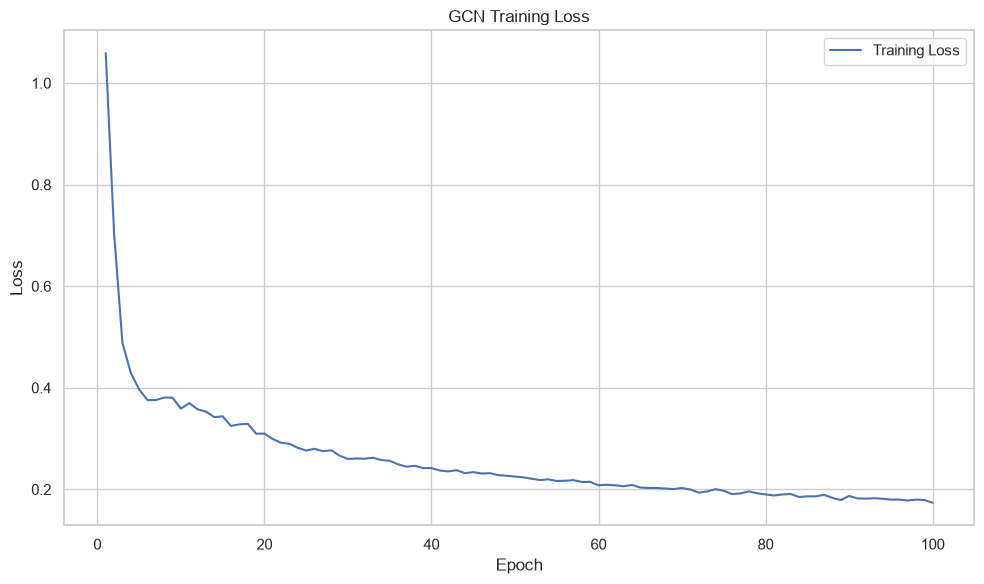

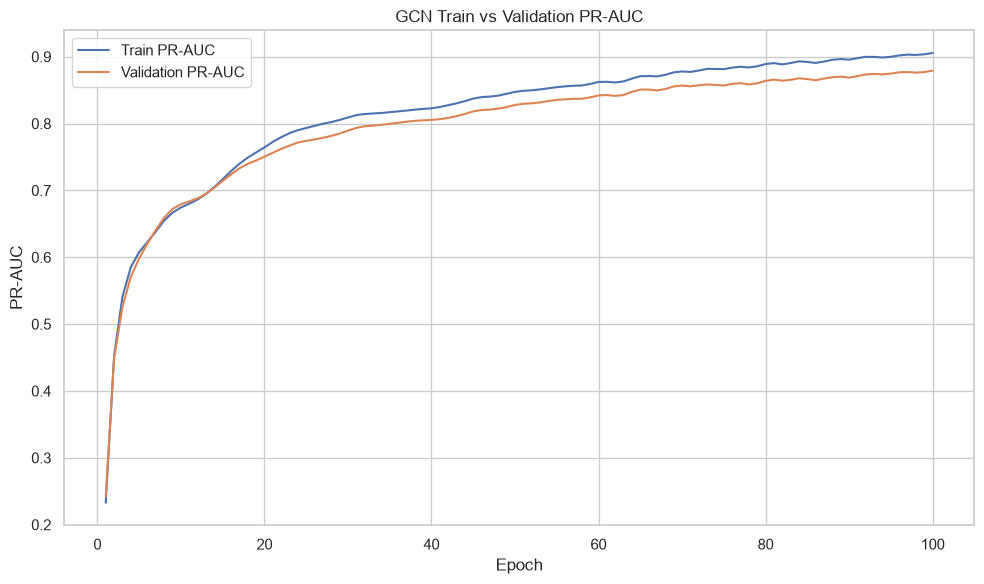

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(history_df["epoch"], history_df["loss"], label="Training Loss")
plt.title("GCN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gcn_training_loss.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history_df["epoch"], history_df["train_pr_auc"], label="Train PR-AUC")
plt.plot(history_df["epoch"], history_df["val_pr_auc"], label="Validation PR-AUC")
plt.title("GCN Train vs Validation PR-AUC")
plt.xlabel("Epoch")
plt.ylabel("PR-AUC")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gcn_train_val_pr_auc.png", dpi=300)
plt.show()

## 7.6 Evaluate the Best GCN Model

The best GCN model is reloaded using the epoch that achieved the highest validation PR-AUC. It is then evaluated on the validation and test sets.

In [10]:
best_gcn_model = GCNModel(
    input_dim=input_dim,
    hidden_dim=64,
    output_dim=2,
    dropout=0.5
).to(device)

best_gcn_model.load_state_dict(
    torch.load(best_model_path, map_location=device)
)

print("Best GCN model loaded from:")
print(best_model_path.relative_to(PROJECT_DIR))

Best GCN model loaded from:
models\gcn_best_model.pt


In [11]:
gcn_val_metrics, gcn_val_cm, y_val_true, y_val_pred, y_val_proba = evaluate_model(
    best_gcn_model,
    data,
    data.val_mask
)

gcn_test_metrics, gcn_test_cm, y_test_true, y_test_pred, y_test_proba = evaluate_model(
    best_gcn_model,
    data,
    data.test_mask
)

print("GCN Validation Metrics:")
for key, value in gcn_val_metrics.items():
    print(f"{key}: {value:.4f}")

print("\nGCN Test Metrics:")
for key, value in gcn_test_metrics.items():
    print(f"{key}: {value:.4f}")

print("\nGCN Test Classification Report:")
print(classification_report(y_test_true, y_test_pred, digits=4))

GCN Validation Metrics:
accuracy: 0.9337
precision: 0.6049
recall: 0.9263
f1: 0.7319
roc_auc: 0.9781
pr_auc: 0.8792

GCN Test Metrics:
accuracy: 0.9336
precision: 0.6075
recall: 0.9043
f1: 0.7268
roc_auc: 0.9765
pr_auc: 0.8610

GCN Test Classification Report:
              precision    recall  f1-score   support

           0     0.9891    0.9368    0.9622      8404
           1     0.6075    0.9043    0.7268       909

    accuracy                         0.9336      9313
   macro avg     0.7983    0.9206    0.8445      9313
weighted avg     0.9518    0.9336    0.9393      9313



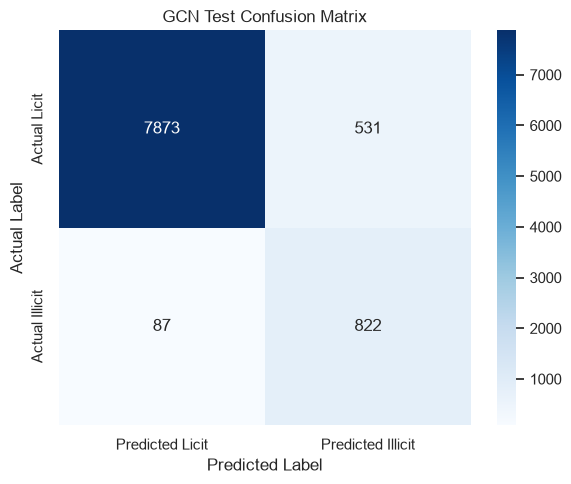

array([[7873,  531],
       [  87,  822]])

In [12]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    gcn_test_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Licit", "Predicted Illicit"],
    yticklabels=["Actual Licit", "Actual Illicit"]
)
plt.title("GCN Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gcn_test_confusion_matrix.png", dpi=300)
plt.show()

gcn_test_cm

In [13]:
gcn_results = {
    "best_epoch": int(best_epoch),
    "best_validation_pr_auc": float(best_val_pr_auc),
    "validation_metrics": {k: float(v) for k, v in gcn_val_metrics.items()},
    "test_metrics": {k: float(v) for k, v in gcn_test_metrics.items()},
    "test_confusion_matrix": gcn_test_cm.tolist()
}

gcn_metrics_path = RESULTS_DIR / "gcn_metrics_summary.json"
gcn_test_results_path = RESULTS_DIR / "gcn_test_results.csv"

with open(gcn_metrics_path, "w") as f:
    json.dump(gcn_results, f, indent=4)

pd.DataFrame([{
    "model": "GCN",
    "accuracy": gcn_test_metrics["accuracy"],
    "precision": gcn_test_metrics["precision"],
    "recall": gcn_test_metrics["recall"],
    "f1": gcn_test_metrics["f1"],
    "roc_auc": gcn_test_metrics["roc_auc"],
    "pr_auc": gcn_test_metrics["pr_auc"]
}]).to_csv(
    gcn_test_results_path,
    index=False
)

print("GCN results saved.")
print(gcn_metrics_path.relative_to(PROJECT_DIR))
print(gcn_test_results_path.relative_to(PROJECT_DIR))

GCN results saved.
results\gcn_metrics_summary.json
results\gcn_test_results.csv


## 7.7 GCN Baseline Summary

This notebook trained a baseline Graph Convolutional Network on the prepared Elliptic transaction graph. The model used the full graph structure for message passing, while supervised loss and evaluation were applied only to labeled nodes. The best model was selected using validation PR-AUC because the dataset is highly imbalanced.

The GCN results will later be compared with Logistic Regression, Random Forest, XGBoost, and GAT to determine whether graph-based learning provides additional value over strong tabular baselines.

## 7.8 Threshold Tuning for GCN

The default GCN predictions are based on the class with the highest predicted probability. Since fraud detection is an imbalanced classification problem, it is useful to examine whether changing the decision threshold improves the balance between precision and recall. The threshold is selected using the validation set and then applied to the test set.

In [14]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_val_true, y_val_proba)

# precision and recall have one extra value compared to thresholds
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best validation threshold based on F1:", round(best_threshold, 4))
print("Validation precision at best threshold:", round(precisions[best_idx], 4))
print("Validation recall at best threshold:", round(recalls[best_idx], 4))
print("Validation F1 at best threshold:", round(f1_scores[best_idx], 4))

Best validation threshold based on F1: 0.7797
Validation precision at best threshold: 0.8348
Validation recall at best threshold: 0.8119
Validation F1 at best threshold: 0.8232


In [15]:
gcn_test_pred_tuned = (y_test_proba >= best_threshold).astype(int)

gcn_test_metrics_tuned = {
    "accuracy": accuracy_score(y_test_true, gcn_test_pred_tuned),
    "precision": precision_score(y_test_true, gcn_test_pred_tuned, zero_division=0),
    "recall": recall_score(y_test_true, gcn_test_pred_tuned, zero_division=0),
    "f1": f1_score(y_test_true, gcn_test_pred_tuned, zero_division=0),
    "roc_auc": roc_auc_score(y_test_true, y_test_proba),
    "pr_auc": average_precision_score(y_test_true, y_test_proba)
}

gcn_test_cm_tuned = confusion_matrix(y_test_true, gcn_test_pred_tuned)

print("GCN Tuned-Threshold Test Metrics:")
for key, value in gcn_test_metrics_tuned.items():
    print(f"{key}: {value:.4f}")

print("\nGCN Tuned-Threshold Test Classification Report:")
print(classification_report(y_test_true, gcn_test_pred_tuned, digits=4))

print("\nTuned-threshold confusion matrix:")
print(gcn_test_cm_tuned)

GCN Tuned-Threshold Test Metrics:
accuracy: 0.9644
precision: 0.8297
recall: 0.7987
f1: 0.8139
roc_auc: 0.9765
pr_auc: 0.8610

GCN Tuned-Threshold Test Classification Report:
              precision    recall  f1-score   support

           0     0.9783    0.9823    0.9803      8404
           1     0.8297    0.7987    0.8139       909

    accuracy                         0.9644      9313
   macro avg     0.9040    0.8905    0.8971      9313
weighted avg     0.9638    0.9644    0.9640      9313


Tuned-threshold confusion matrix:
[[8255  149]
 [ 183  726]]


In [16]:
gcn_tuned_results = {
    "selected_threshold": float(best_threshold),
    "test_metrics_tuned_threshold": {k: float(v) for k, v in gcn_test_metrics_tuned.items()},
    "test_confusion_matrix_tuned_threshold": gcn_test_cm_tuned.tolist()
}

with open(RESULTS_DIR / "gcn_tuned_threshold_results.json", "w") as f:
    json.dump(gcn_tuned_results, f, indent=4)

pd.DataFrame([{
    "model": "GCN_tuned_threshold",
    "threshold": best_threshold,
    "accuracy": gcn_test_metrics_tuned["accuracy"],
    "precision": gcn_test_metrics_tuned["precision"],
    "recall": gcn_test_metrics_tuned["recall"],
    "f1": gcn_test_metrics_tuned["f1"],
    "roc_auc": gcn_test_metrics_tuned["roc_auc"],
    "pr_auc": gcn_test_metrics_tuned["pr_auc"]
}]).to_csv(
    RESULTS_DIR / "gcn_tuned_threshold_test_results.csv",
    index=False
)

print("Tuned-threshold GCN results saved.")

Tuned-threshold GCN results saved.


Threshold tuning was used to examine whether the GCN decision boundary could be improved for the imbalanced fraud detection setting. The threshold was selected using the validation set and then evaluated on the test set. This provides an additional comparison point alongside the default GCN predictions.